<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab2_inductance/blob/main/2026.04/Bz_direct_BiotSavart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Off-axis magnetic field $B_z(r, z)$ — direct Biot-Savart integration

This notebook computes the axial component of the magnetic field $B_z(r, z)$ of a cylindrical
permanent magnet using **direct numerical integration** of the Biot-Savart law.

## Model

The magnet (radius $b$, half-height $l$, remanence $B_r = \mu_0 M$) is modelled as a
**surface solenoid**: a sheet of azimuthal current $K = M$ [A/m] on the cylindrical surface.
This is exact for a uniformly magnetized cylinder.

Each strip $dz'$ at position $z'$ carries current $dI = M\,dz'$ in a ring of radius $b$.
The total field is:

$$B_z(r,z) = \frac{\mu_0 M}{4\pi} \int_{-l}^{+l} dz' \int_0^{2\pi} d\varphi\;
\frac{b\,(b - r\cos\varphi)}{\left[r^2 + b^2 - 2br\cos\varphi + (z-z')^2\right]^{3/2}}$$

## Advantages over elliptic integral approach

- **Continuous everywhere** including $r = 0$ and $r = b$ — no special cases needed
- **Transparent**: directly implements the physical law
- **Easy to modify**: change geometry, add layers, etc.

## Key finding

Near the magnet ($z \lesssim l$), $B_z$ is large and positive on the axis but
**changes sign** at $r \gtrsim b$ (return flux region). A pickup coil of radius $R > b$
integrates over both regions, so $\langle B_z\rangle_R \ll B_z(0,z)$.
This explains the factor-of-3–4 discrepancy between dynamic coil and teslameter measurements.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [18]:
mu0 = 4 * np.pi * 1e-7   # H/m

# --- Magnet ---
b  = 1e-2    # radius [m]
l  = 1e-2    # half-height [m]
Br = 1.090   # remanence [T]  (fitted from teslameter data)
M  = Br / mu0  # magnetization [A/m]

# --- Pickup coil ---
R_coil = 17.5e-3   # radius [m]

print(f"Magnet:      radius b = {b*100:.1f} cm,  half-height l = {l*100:.1f} cm")
print(f"             Br = {Br*1000:.0f} mT,  M = {M:.3e} A/m")
print(f"Pickup coil: radius R = {R_coil*100:.2f} cm")

Magnet:      radius b = 1.0 cm,  half-height l = 1.0 cm
             Br = 1090 mT,  M = 8.674e+05 A/m
Pickup coil: radius R = 1.75 cm


## Core functions

### Biot-Savart for one current ring

For a ring of radius $a$ at $z'=0$ carrying current $I$, the $z$-component of the field
at $(r, z_\text{rel})$ is obtained by integrating the Biot-Savart law over the azimuthal angle $\varphi$:

$$B_z = \frac{\mu_0 I\, a}{4\pi} \int_0^{2\pi}
\frac{a - r\cos\varphi}{\left[r^2 + a^2 - 2ar\cos\varphi + z_\text{rel}^2\right]^{3/2}}\,d\varphi$$

This expression is **continuous and finite for all** $(r, z_\text{rel})$ including $r=0$.

In [3]:
def Bz_ring(a, z_rel, r, I=1.0, n_phi=300):
    """
    Bz at (r, z_rel) from a current ring of radius a at z=0, current I.
    Direct Biot-Savart integration over azimuthal angle phi.
    Continuous everywhere — no special treatment at r=0 or r=a.

    Parameters
    ----------
    a     : ring radius [m]
    z_rel : z_obs - z_ring  [m]
    r     : radial coordinate of field point [m]
    I     : current [A]
    n_phi : number of integration steps (300 gives < 0.1% error)

    Returns
    -------
    Bz [T]
    """
    phi  = np.linspace(0, 2*np.pi, n_phi, endpoint=False)
    dphi = phi[1] - phi[0]

    # Denominator: distance^3 from source element to field point
    R2 = r**2 + a**2 - 2*a*r*np.cos(phi) + z_rel**2
    R3 = R2**1.5

    # z-component of (dl x R_hat): numerator factor
    # dl = a*dphi * (-sin phi, cos phi, 0)
    # R  = (r - a*cos phi, -a*sin phi, z_rel)  [field point minus source]
    # (dl x R)_z = a*dphi * [(-sin phi)*(-a*sin phi) - (cos phi)*(r - a*cos phi)]
    #            = a*dphi * (a - r*cos phi)
    integrand = (a - r*np.cos(phi)) / R3

    return mu0 * I * a / (4*np.pi) * np.sum(integrand) * dphi


def Bz_magnet(z_obs, r_obs, n_z=400, n_phi=300):
    """
    Bz at (r_obs, z_obs) from the cylindrical magnet.
    Surface solenoid: K = M [A/m], rings from z'=-l to +l.

    Parameters
    ----------
    z_obs  : axial position from magnet center [m]
    r_obs  : radial position [m]
    n_z    : number of source rings along z'
    n_phi  : azimuthal integration steps per ring

    Returns
    -------
    Bz [T]
    """
    zp  = np.linspace(-l, l, n_z)
    dzp = zp[1] - zp[0]
    # Each strip dz' carries current dI = M * dz'
    Bz = sum(
        Bz_ring(b, z_obs - zp_i, r_obs, I=M*dzp, n_phi=n_phi)
        for zp_i in zp
    )
    return Bz


def Bz_axis_analytic(z):
    """Exact on-axis Bz — closed form, for comparison."""
    s1 = (z + l) / np.sqrt((z + l)**2 + b**2)
    s2 = (z - l) / np.sqrt((z - l)**2 + b**2)
    return mu0 * M / 2 * (s1 - s2)

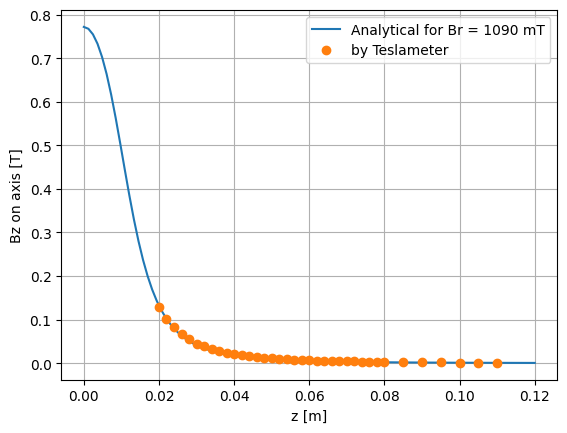

In [21]:
measurements = '''
#Z [m],B [T]
0.02,0.13
0.022,0.1008
0.024,0.0831
0.026,0.0681
0.028,0.0553
0.03,0.0451
0.032,0.0384
0.034,0.0318
0.036,0.0278
0.038,0.0238
0.04,0.021
0.042,0.0178
0.044,0.0159
0.046,0.014
0.048,0.0125
0.05,0.0111
0.052,0.00996
0.054,0.00893
0.056,0.00771
0.058,0.0073
0.06,0.00657
0.062,0.00603
0.064,0.0055
0.066,0.00501
0.068,0.00464
0.07,0.00426
0.072,0.00395
0.074,0.00365
0.076,0.00341
0.078,0.00313
0.08,0.00293
0.085,0.00246
0.09,0.00211
0.095,0.00182
0.1,0.0016
0.105,0.0014
0.11,0.00125
'''
z_measured, B_measured = np.genfromtxt(measurements.splitlines(), delimiter=',', skip_header=1, unpack=True)
z_dense = np.linspace(0, 0.12, 100)
B_dense = np.array([Bz_magnet(z, 0) for z in z_dense])
plt.plot(z_dense, B_dense, label=f'Analytical for Br = {Br*1e3:.0f} mT')
plt.plot(z_measured, B_measured, 'o', label='by Teslameter')
plt.xlabel('z [m]')
plt.ylabel('Bz on axis [T]')
plt.legend()
plt.grid()

## Verification

### 1. On-axis: numerical vs analytic

In [22]:
print(f"{'z [cm]':>8}  {'Analytic [mT]':>14}  {'Numeric [mT]':>14}  {'error [%]':>10}")
print("-" * 52)
for z_cm in [0, 1, 2, 3, 5, 10]:
    z  = z_cm * 1e-2
    Ba = Bz_axis_analytic(z)
    Bn = Bz_magnet(z, 0)
    print(f"{z_cm:>8}  {Ba*1000:>14.2f}  {Bn*1000:>14.2f}  {(Bn/Ba-1)*100:>+9.3f}%")

  z [cm]   Analytic [mT]    Numeric [mT]   error [%]
----------------------------------------------------
       0          770.75          771.71     +0.125%
       1          487.46          488.95     +0.305%
       2          131.66          132.19     +0.400%
       3           41.26           41.41     +0.344%
       5            8.86            8.88     +0.289%
      10            1.10            1.10     +0.261%


### 2. Continuity at $r = 0$

In [23]:
z_test = 2e-2
Ba = Bz_axis_analytic(z_test)
print(f"z = {z_test*100:.0f} cm  —  analytic on-axis: {Ba*1000:.4f} mT")
print()
print(f"{'r [mm]':>10}  {'Bz_numeric [mT]':>16}  {'diff from axis [%]':>20}")
print("-" * 50)
for r_mm in [10, 1, 0.1, 0.01, 0.001, 0.0]:
    Bn = Bz_magnet(z_test, r_mm*1e-3)
    print(f"{r_mm:>10.3f}  {Bn*1000:>16.4f}  {(Bn/Ba-1)*100:>+19.4f}%")

z = 2 cm  —  analytic on-axis: 131.6592 mT

    r [mm]   Bz_numeric [mT]    diff from axis [%]
--------------------------------------------------
    10.000           73.1661             -44.4277%
     1.000          131.4998              -0.1211%
     0.100          132.1790              +0.3948%
     0.010          132.1858              +0.4000%
     0.001          132.1859              +0.4000%
     0.000          132.1859              +0.4000%


## Compute $B_z(r)$ profiles at fixed $z$

A uniform radial grid — no special treatment near $r = b$.

In [29]:
r_arr = np.linspace(0, R_coil, 200)   # 0 to R cm, uniform

z_values_cm = [0, 1, 2, 3, 4, 5]
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']

print("Computing Bz(r) profiles ... (takes ~1–2 min)")
results = {}
for z_cm in z_values_cm:
    z  = z_cm * 1e-2
    Bz = np.array([Bz_magnet(z, r) for r in r_arr])
    results[z_cm] = Bz
    sign = " ← sign change (return flux)" if Bz[0]*np.interp(R_coil, r_arr, Bz) < 0 else ""
    print(f"  z={z_cm} cm:  B(r=0)={Bz[0]*1000:7.1f} mT   "
          f"B(r=b)={np.interp(b, r_arr, Bz)*1000:7.1f} mT   "
          f"B(r=R)={np.interp(R_coil, r_arr, Bz)*1000:7.1f} mT{sign}")
print("Done.")

Computing Bz(r) profiles ... (takes ~1–2 min)
  z=0 cm:  B(r=0)=  771.7 mT   B(r=b)= -314.7 mT   B(r=R)=  -77.6 mT ← sign change (return flux)
  z=1 cm:  B(r=0)=  489.0 mT   B(r=b)= -805.0 mT   B(r=R)=  -29.3 mT ← sign change (return flux)
  z=2 cm:  B(r=0)=  132.2 mT   B(r=b)=   73.2 mT   B(r=R)=   19.8 mT
  z=3 cm:  B(r=0)=   41.4 mT   B(r=b)=   30.2 mT   B(r=R)=   16.4 mT
  z=4 cm:  B(r=0)=   17.4 mT   B(r=b)=   14.5 mT   B(r=R)=   10.1 mT
  z=5 cm:  B(r=0)=    8.9 mT   B(r=b)=    7.9 mT   B(r=R)=    6.2 mT
Done.


## Plot 1: Linear scale

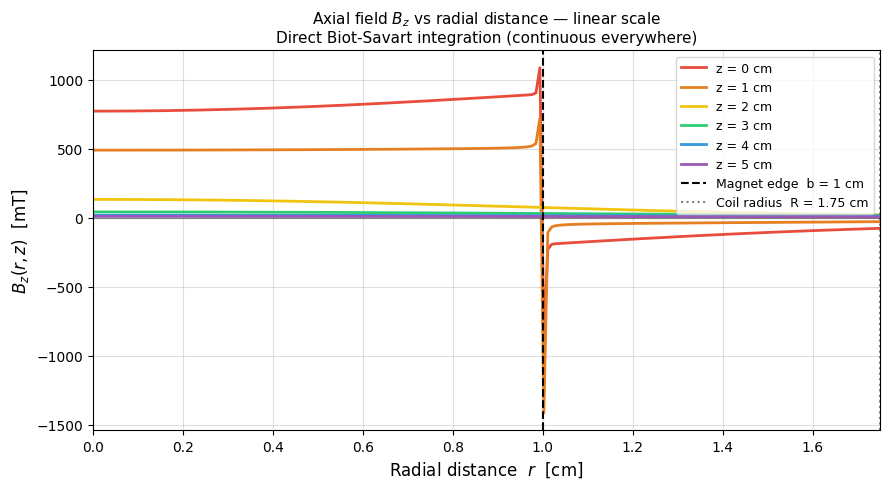

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

for z_cm, col in zip(z_values_cm, colors):
    ax.plot(r_arr*100, results[z_cm]*1000, color=col, lw=2, label=f'z = {z_cm} cm')

ax.axvline(b*100,      color='black', lw=1.5, ls='--', label=f'Magnet edge  b = {b*100:.0f} cm')
ax.axvline(R_coil*100, color='gray',  lw=1.5, ls=':',  label=f'Coil radius  R = {R_coil*100:.2f} cm')
ax.axhline(0, color='black', lw=0.8, alpha=0.4)

ax.set_xlabel('Radial distance  $r$  [cm]', fontsize=12)
ax.set_ylabel('$B_z(r, z)$  [mT]', fontsize=12)
ax.set_title('Axial field $B_z$ vs radial distance — linear scale\n'
             'Direct Biot-Savart integration (continuous everywhere)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.4)
ax.set_xlim(0, 1.75)
plt.tight_layout()
plt.show()

## Plot 2: Log scale

Solid: $B_z > 0$.  Dashed: $|B_z|$ where $B_z < 0$ (return flux region).

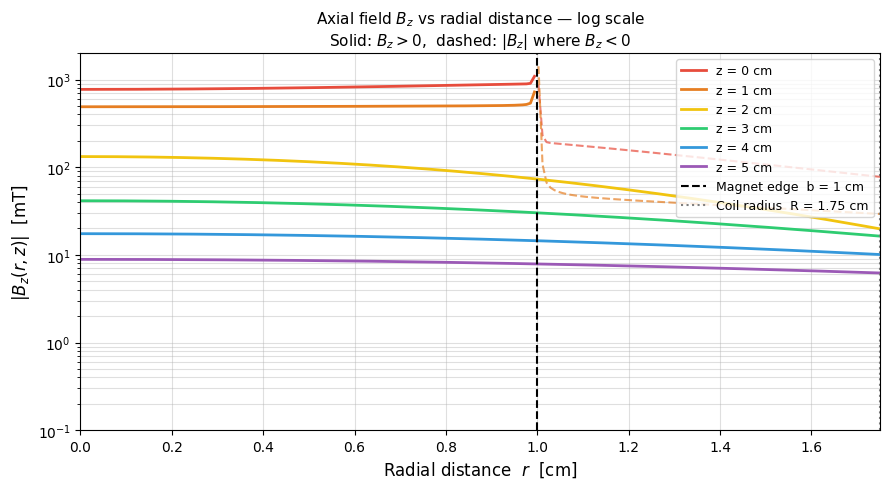

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))

for z_cm, col in zip(z_values_cm, colors):
    Bz  = results[z_cm]
    pos = np.where(Bz >  0,  Bz, np.nan)
    neg = np.where(Bz <  0, -Bz, np.nan)
    ax.semilogy(r_arr*100, pos*1000, color=col, lw=2,   label=f'z = {z_cm} cm')
    ax.semilogy(r_arr*100, neg*1000, color=col, lw=1.5, ls='--', alpha=0.7)

ax.axvline(b*100,      color='black', lw=1.5, ls='--', label=f'Magnet edge  b = {b*100:.0f} cm')
ax.axvline(R_coil*100, color='gray',  lw=1.5, ls=':',  label=f'Coil radius  R = {R_coil*100:.2f} cm')

ax.set_xlabel('Radial distance  $r$  [cm]', fontsize=12)
ax.set_ylabel('$|B_z(r, z)|$  [mT]', fontsize=12)
ax.set_title('Axial field $B_z$ vs radial distance — log scale\n'
             'Solid: $B_z > 0$,  dashed: $|B_z|$ where $B_z < 0$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.4, which='both')
ax.set_xlim(0, R_coil*1e2)
ax.set_ylim(0.1, 2000)
plt.tight_layout()
plt.show()

## Plot 3: Flux average $\langle B_z \rangle_R$ vs on-axis $B_z$

The pickup coil measures $\langle B_z\rangle_R = \Phi/(\pi R^2)$;  
the teslameter measures $B_z(r=0, z)$.

In [36]:
def flux_avg_Bz(z_obs, R_coil, n_r=80):
    """
    Area-averaged <Bz> over a disc of radius R_coil at height z_obs.
    Phi = int_0^R Bz(r,z) * 2*pi*r dr
    <Bz> = Phi / (pi * R^2)
    """
    r_pts     = np.linspace(0, R_coil, n_r)
    integrand = np.array([Bz_magnet(z_obs, r) * 2*np.pi*r for r in r_pts])
    Phi       = np.trapezoid(integrand, r_pts)
    return Phi / (np.pi * R_coil**2)


z_arr  = np.linspace(0, 0.12, 35)
B_ax   = np.array([Bz_axis_analytic(z) for z in z_arr])
B_avg  = np.array([flux_avg_Bz(z, R_coil) for z in z_arr])
ratio  = B_avg / B_ax



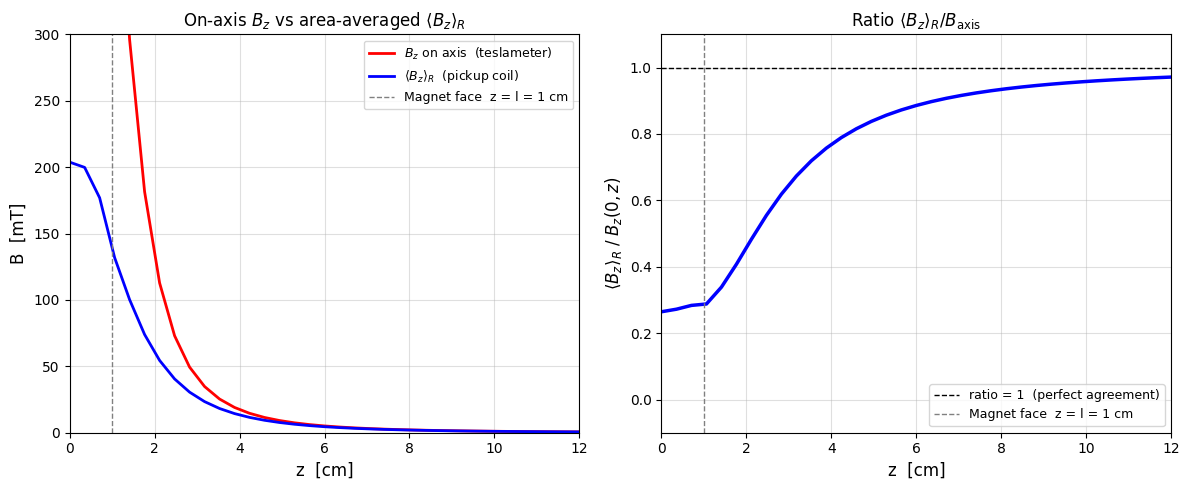

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: both fields on log scale
ax = axes[0]
ax.plot(z_arr*100, B_ax*1000,  'r-', lw=2, label='$B_z$ on axis  (teslameter)')
ax.plot(z_arr*100, B_avg*1000, 'b-', lw=2, label=r'$\langle B_z\rangle_R$  (pickup coil)')
ax.axvline(l*100,      color='gray',   ls='--', lw=1, label=f'Magnet face  z = l = {l*100:.0f} cm')
#ax.axvline(R_coil*100, color='orange', ls=':',  lw=1, label=f'z = R_coil = {R_coil*100:.2f} cm')
ax.set_xlabel('z  [cm]', fontsize=12)
ax.set_ylabel('B  [mT]', fontsize=12)
ax.set_title('On-axis $B_z$ vs area-averaged $\\langle B_z\\rangle_R$', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4, which='both')
ax.set_xlim(0, 12)
ax.set_ylim(0, 300)
# Right: ratio
ax = axes[1]
ax.plot(z_arr*100, ratio, 'b-', lw=2.5)
ax.axhline(1.0, color='black', ls='--', lw=1,   label='ratio = 1  (perfect agreement)')
#ax.axhline(0.5, color='orange', ls=':',  lw=1.5, label='ratio = 0.5  (dipole limit, large z)')
ax.axvline(l*100,      color='gray',   ls='--', lw=1, label=f'Magnet face  z = l = {l*100:.0f} cm')
#ax.axvline(R_coil*100, color='orange', ls=':',  lw=1)
# Mark z values from the Bz(r) plots
ax.set_xlabel('z  [cm]', fontsize=12)
ax.set_ylabel(r'$\langle B_z\rangle_R \;/\; B_z(0,z)$', fontsize=12)
ax.set_title(r'Ratio $\langle B_z\rangle_R / B_{\rm axis}$', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
ax.set_xlim(0, 12)
ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()

## Summary table

In [10]:
print(f"{'z [cm]':>8}  {'B(r=0) [mT]':>13}  {'B(r=b) [mT]':>13}  "
      f"{'B(r=R) [mT]':>13}  {'sign change?':>16}")
print("-" * 72)
for z_cm in z_values_cm:
    Bz = results[z_cm]
    b0 = Bz[0]
    bb = float(np.interp(b,      r_arr, Bz))
    bR = float(np.interp(R_coil, r_arr, Bz))
    note = "YES — return flux" if b0 * bR < 0 else ""
    print(f"{z_cm:>8}  {b0*1000:>13.1f}  {bb*1000:>13.1f}  {bR*1000:>13.1f}  {note:>16}")

  z [cm]    B(r=0) [mT]    B(r=b) [mT]    B(r=R) [mT]      sign change?
------------------------------------------------------------------------
       0          773.8          -53.5          -77.9  YES — return flux
       1          490.3          -29.0          -29.4  YES — return flux
       2          132.5           73.4           19.9                  
       3           41.5           30.3           16.4                  
       4           17.5           14.5           10.1                  
       5            8.9            7.9            6.2                  


## Physical interpretation

**Why does $B_z$ change sign?**

Magnetic flux lines form closed loops ($\nabla\cdot\mathbf{B} = 0$). The strong axial flux
through the magnet center must return via a radially outward path just beyond the magnet edge
$r > b$. At $z \approx 0$ and $z \approx l$, this return flux creates a region of **negative** $B_z$
for $r \gtrsim b$.

**Consequence for the pickup coil ($R > b$):**

$$\langle B_z\rangle_R = \frac{1}{\pi R^2}\int_0^R B_z(r,z)\,2\pi r\,dr$$

The coil integrates over both the positive core region and the negative annulus.
The partial cancellation makes $\langle B_z\rangle_R \ll B_z(0,z)$ near the magnet —
a factor of 3–4 at $z \sim 0$–$1$ cm — which explains the discrepancy between
dynamic (coil) and static (teslameter) measurements of the magnetic field.